<center><img src="https://i.imgur.com/YNtjmbq.png" width="800"></center> 

<a target="_blank" href="https://colab.research.google.com/github/MAGALLANESJoseManuel/MGPIT_Pol748_Redes_2/blob/main/sesion_2.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# EXPLORACION DE REDES Y SUS NODOS


<div class="alert alert-info" role="alert">
    
**Data para la sesión**

Para esta sesión, los datos puedes descargarlos en _tu_ carpeta **data** desde este [enlace](https://drive.google.com/drive/folders/1xri-lWtXZv-7Ce5_xJ31GQFVnJZJ1zeo?usp=sharing).
</div>



En el año 2018, Quinten Dol sugirió a los usuarios de Twitter seguir a estas celebridades de la Tecnologia local:


<a href="https://www.builtinseattle.com/articles/50-seattle-tech-twitter-accounts-to-follow" target="_blank">
    <img src="https://github.com/maestriaInnovacion-magallanes-redes/exploracion/raw/main/picsForSession/influentialTweet.jpg
" alt="Influential Tweet" style="max-width: 100%; height: auto;">
</a>

Aunque proponía 50 _influencers_, sólo hay 46 activos en X (antes Twitter). Se construyó una red para ver si entre ellos se seguían, y [esto tenemos](https://docs.google.com/spreadsheets/u/1/d/e/2PACX-1vQaaNQb2frjnlt0fPSBQhp5tNydB0a9ibp98sblBn6OfvGd8vsx8cfHb4w8Cm_qC3EIeYFby_zNQBoK/pubhtml):

In [1]:
from IPython.display import IFrame
IFrame('https://docs.google.com/spreadsheets/d/e/2PACX-1vQvzPtFqK2pgq8xGLZy4EsGyT0RU-3ghuqhJOmEm8J0YEZ1SOjXn1aLGZmKIUmTGRr-ww1jdULhAPvz/pubhtml', 800, 350)

## Creando la red

Como ya sabemos, la red se arma con la **adjacency matrix** o la **edgelist**. Hagámoslo nuevamente:

In [2]:
# librerias necesarias
import networkx as nx
import pandas as pd

# link a GoogleDrive como un Excel
linkGoogle="https://docs.google.com/spreadsheets/d/e/2PACX-1vQvzPtFqK2pgq8xGLZy4EsGyT0RU-3ghuqhJOmEm8J0YEZ1SOjXn1aLGZmKIUmTGRr-ww1jdULhAPvz/pub?output=xlsx"

# leyendo archivo de red
adjacency=pd.read_excel(linkGoogle,   
                        index_col=0,  # la columna '0' guarda los nombres
                        sheet_name='adjacency') # la tabla tiene este nombre



Los grafos de las tredes sociales como `Twitter` / `X` son generalmente **dirigidos** pues un nodo sigue a otro, pero la relación no es necesariamente recíproca. 

In [3]:
# creando red dirigida
TopFromAdjacency=nx.from_pandas_adjacency(adjacency,create_using=nx.DiGraph)
# info de lo que tenemos
print(TopFromAdjacency)

DiGraph with 46 nodes and 588 edges


El objeto **TopFromAdjacency** contiene a la `red dirigida`.

¿Tendremos algun _influencer_ que no siga a otro ni sea seguido por otro?

In [4]:
list(nx.isolates(TopFromAdjacency))

[]

De ahi que la red no mostrará nodos aislados:

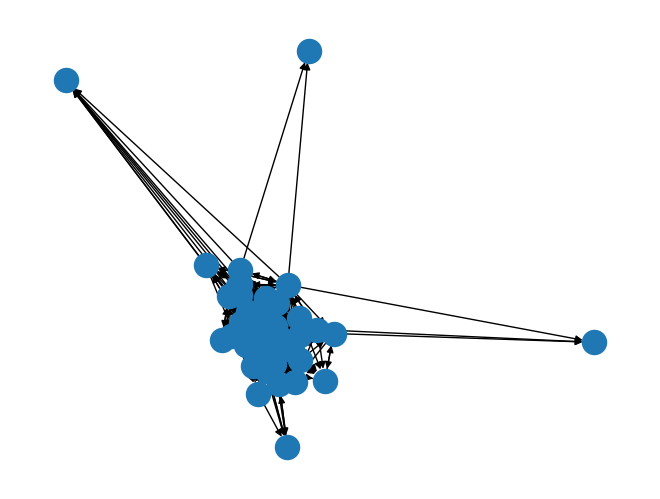

In [5]:
nx.draw(TopFromAdjacency)

## Añadiendo atributos

Notese que tenemos atributos para la red:

In [6]:
atributos=pd.read_excel(linkGoogle,   
                        index_col=0,  # la columna '0' guarda los nombres
                        sheet_name='attributes') # la tabla tiene este nombre

# nota que la columna 1 la abrí como el nombre de fila (index)
atributos

,male,followers
Id,,
rachelerman,0,7139
mattmcilwain,1,2804
DaveParkerSEA,1,3328
toddbishop,1,24500
ashannstew,0,3382
LeslieFeinzaig,0,15900
akipman,1,29500
matt_oppy,1,4847
gilbert,1,25800


Los atributos de cada nodo deben ser parte de la red dirigida actual. El proceso es simple:

In [7]:
# Convertimos el DataFrame en un diccionario indexado por el nodo
atributos_nodos = atributos.to_dict('index')

# Pasamos todos los atributos al grafo de un solo golpe
nx.set_node_attributes(TopFromAdjacency, atributos_nodos)

Podemos verificarlo asi:

In [8]:
TopFromAdjacency.nodes(data=True)

NodeDataView({'rachelerman': {'male': 0, 'followers': 7139}, 'mattmcilwain': {'male': 1, 'followers': 2804}, 'DaveParkerSEA': {'male': 1, 'followers': 3328}, 'toddbishop': {'male': 1, 'followers': 24500}, 'ashannstew': {'male': 0, 'followers': 3382}, 'LeslieFeinzaig': {'male': 0, 'followers': 15900}, 'akipman': {'male': 1, 'followers': 29500}, 'matt_oppy': {'male': 1, 'followers': 4847}, 'gilbert': {'male': 1, 'followers': 25800}, 'juliesandler': {'male': 0, 'followers': 7031}, 'BradSmi': {'male': 1, 'followers': 96300}, 'crashdev': {'male': 0, 'followers': 8773}, 'ShaunaCausey': {'male': 0, 'followers': 47400}, 'john_gabbert': {'male': 1, 'followers': 2482}, 'moniguzman': {'male': 0, 'followers': 29000}, 'mattmday': {'male': 1, 'followers': 5750}, 'Rich_Barton': {'male': 1, 'followers': 31300}, 'daryn': {'male': 1, 'followers': 2378}, 'lovelletters': {'male': 0, 'followers': 4553}, 'etzioni': {'male': 1, 'followers': 27400}, 'MissDestructo': {'male': 0, 'followers': 41800}, 'heatherre

Ya con esto, podemos exportarlo:

In [9]:
filename1='seattle.gml' # nombre incluye 'donde'
filename2='seattle.graphml'

# guardando:
nx.write_gml(TopFromAdjacency,filename1)

nx.write_graphml(TopFromAdjacency,filename2)

<div class="alert alert-warning" role="alert">
    
#### En Gephi  
    
**Usa GEPHI y abre la red de los tech influencers de Seattle.**

</div>

Gephi abre los archivos `gml` o `graphml` directamente. Pero si no quieres pasar por Python y usar el Excel directamente, requiere dos pasos:
1. Importar la matriz desde excel (visto enla primera sesión)
2. Importar y combinar los atributos desde Excel.

 El segundo paso lo detallo a continuación:

La importación usa la misma opción del menú: `importar hoja de calculo` (como lo usaste con la matriz), pero esta vez hay otras opciones a elegir:

<img src="https://github.com/maestriaInnovacion-magallanes-redes/exploracion/raw/main/picsForSession/importAttr1.jpg"/>


En el siguiente paso, elije el tipo respectivo de datos para cada columna, por ejemplo:
<img src="https://github.com/maestriaInnovacion-magallanes-redes/exploracion/raw/main/picsForSession/importAttr2.jpg"/>


Por lo general, podemos explorar la red de dos maneras:

1. A nivel de red en total.
2. A nivel de cada actor (nodo).

# 1. Explorando a nivel de red

A continuación, se detallan las métricas fundamentales para comprender la red como una entidad completa.

| Indicador Global | ¿Sensible a la Dirección (Dirigido)? | Rango de Valores Teóricos | Interpretación Concreta y Simple |
| --- | --- | --- | --- |
| **Conectividad** | **Sí** *(Genera componentes fuertes y débiles)* | Cualitativo / Booleano | Evalúa si la red está integrada o fragmentada. Determina si existen caminos que permitan viajar entre cualquier par de nodos del grafo. |
| **Diámetro** | **Sí** *(Los caminos dirigidos alteran la distancia)* | De $1$ a $N-1$ | **La longitud máxima:** El peor escenario de comunicación. Es el camino más largo de entre todos los caminos más cortos posibles dentro de la red. |
| **Accesibilidad (Distancia Media)** | **Sí** | De $1$ a $N-1$ | **Velocidad promedio:** El número de pasos (saltos) que, en promedio, le toma a un mensaje viajar de un usuario cualquiera a otro dentro del grafo. |
| **Densidad** | **Sí** *(Considera el doble de enlaces posibles)* | De 0% a 100% | **Nivel de interconexión:** Qué porcentaje de todas las relaciones posibles en la red existen realmente. Mide la "cohesión" del ecosistema. |
| **Alcanzabilidad** | **Sí** | De 0% a 100% | **Porcentaje de integración:** Qué proporción de pares de nodos están efectivamente conectados por algún camino. Mide la resiliencia al aislamiento. |
| **Reciprocidad** | **Nativo de Dirigidos** *(No aplica a no dirigidos)* | De 0% a 100% | **Bidireccionalidad:** Qué porcentaje de las relaciones son mutuas (si te sigo, me sigues). Mide la simetría y el nivel de "pacto social" en la red. |

## Conectividad

Una de las primeras interrogantes, es saber si cada nodo puede conectarse con otro nodo. Para que ello sucede, teniendo en cuenta que la red es dirigida, debe haber un **path** o camino (sequencia de flechas) entre todo par de nodos de la red. Si esto fuera así, se debe verificar que la red es **strongly_connected**.

En la Figura 1 vemos una red que tiene componentes fuertemente conectados, pero la red en su totalidad no lo es:
<figure>
<img src="https://github.com/MAGALLANESJoseManuel/MGPIT_Pol748_Redes_2/raw/main/picsForSession/strongly_connected.png" style="width:70%">
<figcaption align = "center"> Figura 1. Red y componentes fuertemente conectados </figcaption>
    <a href="https://en.wikipedia.org/wiki/Strongly_connected_component" class="alert-link">Fuente:Wikipedia</a>
</figure>


Nuestra red tampoco lo es:

In [10]:
nx.is_strongly_connected(TopFromAdjacency)

False

Veamos cuántos hay de cada uno:

In [32]:
# 1. Calcular la cantidad de componentes fuertemente conectados
# (Nodos que pueden ir y venir entre sí siguiendo la dirección de las flechas)
num_strong_components = nx.number_strongly_connected_components(TopFromAdjacency)

# 2. Calcular la cantidad de componentes débilmente conectados
# (Nodos conectados si ignoramos temporalmente la dirección de las flechas)
num_weak_components = nx.number_weakly_connected_components(TopFromAdjacency)

# Desplegar los resultados de forma ejecutiva
print(f"Componentes Fuertemente Conectados (Strong): {num_strong_components}")
print(f"Componentes Débilmente Conectados (Weak): {num_weak_components}")

Componentes Fuertemente Conectados (Strong): 4
Componentes Débilmente Conectados (Weak): 1


<div class="alert alert-warning" role="alert">
    
#### En Gephi  
    
Verificar que los mismos resultados son obtenidos.

</div>

## Distancia y el Geodésico

La **distance** se entiende como la cantidad de _edges_ que separan un par de nodos. Como entre algun par de nodos puede haber muchas distancias, llamamos **geodésico** a la distancia más corta entre dos nodos. La Figura 2 nos muestra algunos geodésicos:

<figure>
<img src="https://github.com/MAGALLANESJoseManuel/MGPIT_Pol748_Redes_2/raw/main/picsForSession/geodesics.png" style="width:70%">
<figcaption align = "center"> Figura 2. Geodésicos. 
 </figcaption>
 <a href="https://www.wolframphysics.org/technical-introduction/limiting-behavior-and-emergent-geometry/geodesics/" class="alert-link">Fuente: Wolframphysics</a>
</figure>

Revisemos los conceptos de **diámetro** y **distancia media**.

### a. Diámetro

Una métrica clave  que podemos calcular de la matriz de geodésicos es el **diámetro**. El diámetro es el máximo de los geodésico, pues representa la distancia mas corta entre las celdas mas alejadas de la red. Veámoslo en la Figura 3.

<figure>
<img src="https://github.com/MAGALLANESJoseManuel/MGPIT_Pol748_Redes_2/raw/main/picsForSession/diameter.png" style="width:70%">
<figcaption align = "center"> Figura 3. Diámetro. 
 </figcaption>
 Fuente: Autor.
</figure>


La función **diameter()** no podemos calcularlo de una red que no se fuertemente conectada. Pero tratemos dos opciones informativas:

In [11]:
# Convertir a no dirigido y calcular el diámetro de la estructura general
diametro_no_dirigido = nx.diameter(TopFromAdjacency.to_undirected())
print(f"Diámetro de la red (Estructura Social no dirigida): {diametro_no_dirigido}")

Diámetro de la red (Estructura Social no dirigida): 3


In [35]:
# 1. Extraer los componentes fuertemente conectados ordenados por tamaño
componentes_fuertes = sorted(nx.strongly_connected_components(TopFromAdjacency), key=len, reverse=True)

# 2. Aislar el subgrafo del componente más grande (el gigante)
componente_gigante_Top = TopFromAdjacency.subgraph(componentes_fuertes[0])

# 3. Calcular el diámetro real de ese núcleo cooperativo
diametro_efectivo = nx.diameter(componente_gigante_Top)
print(f"Diámetro del Componente Fuertemente Conectado Gigante: {diametro_efectivo}")

Diámetro del Componente Fuertemente Conectado Gigante: 4


El diámetro define **el peor escenario posible** (la distancia geodésica más larga) dentro de esta red de 46 líderes tecnológicos. Es la medida exacta de la extensión máxima del tejido social.

> **Diámetro No Dirigido**: Un diámetro de 3 significa que, incluso los dos líderes más alejados entre sí en este ecosistema, están a un máximo de **dos intermediarios** de distancia, algo como (Líder A $\rightarrow$ Líder B $\rightarrow$ Líder C $\rightarrow$ Líder D). Si este es el peor caso, solemos decir qué pequeño es el mundo, y en este campo se le denomina una red tipo `small-world`: nadie en este grupo de 46 personas es un extraño total; todos están integrados en una estructura compacta donde la información técnica no tiene que viajar largas jornadas para cubrir a todo el grupo.

> **Diámetro del Componente Fuertemente Conectado Gigante (GSCC**): Representa un cálculo metodológicamente más riguroso porque respeta la dirección de las flechas (quién sigue a quién) y se enfoca en el núcleo de la red donde existe un camino orientado (directo o indirecto) de ida y vuelta entre cualquier par de nodos. El hecho de que el diámetro aumente a solo 4 pasos al considerar la direccionalidad es un indicador de altísima eficiencia. Significa que el flujo de información es casi tan rápido siguiendo las reglas estrictas de Twitter como si la red fuera totalmente simétrica. Un diámetro dirigido de apenas 4 pasos en este componente gigante garantiza que el intercambio de conocimiento y recursos entre los líderes es fluido, constante y predecible. La red esquiva el riesgo de generar caminos excesivamente largos o laberínticos para conectar a sus miembros orientados.

Anclando estos resultados, se derivan tres conclusiones estructurales sobre el ecosistema:

* **Difusión Masiva:** Las redes sociales en Internet permiten una difusión que marca una gran diferencia por su alcance. Con un diámetro de entre 3 y 4 pasos, esta red opera como un **conducto de información óptimo**. Una innovación lanzada en un extremo del grafo saturará a todo el grupo de líderes en un tiempo récord.
* **Persuasión y Marketing Viral:** En estructuras con estas características morfológicas, la literatura especializada coincide en que *persuadir es un proceso sumamente ágil*. La corta distancia entre los puntos más extremos del tejido facilita que las ideas se compartan rápidamente, acelerando la convergencia cultural y la adopción de tendencias entre todos los miembros.
* **Resiliencia Sistémica:** Al mantener un diámetro tan pequeño, la red no solo es veloz, sino también **altamente robusta**. La comunicación no depende de cadenas de transmisión largas y frágiles que puedan interrumpirse con facilidad, sino que se apoya en una infraestructura de nexos inherentemente cortos y directos.


<div class="alert alert-warning" role="alert">
    
#### En Gephi  
    
Verificar que los mismos resultados son obtenidos.

</div>

### b. Accesibilidad (Distancia Media)

Representa el número promedio de nexos o pasos necesarios para conectar a dos individuos cualesquiera en la red. Describe a la red como un **conducto** por donde fluyen ideas o recursos.


In [36]:
distancia_media_U = nx.average_shortest_path_length(TopFromAdjacency.to_undirected())

    #aqui
distancia_media_U

1.633816425120773

In [37]:
distancia_media_D = nx.average_shortest_path_length(componente_gigante_Top)

    #aqui
distancia_media_D

1.7652270210409746

La distancia media de la red, evaluada en **1.63 pasos** bajo un enfoque no dirigido y en **1.76 pasos** al respetar estrictamente la direccionalidad de los flujos, es un valor notablemente bajo que indica una proximidad excepcional dentro de esta red de 46 líderes tecnológicos. Mientras que la cifra de 1.63 refleja el escenario social potencial de la estructura (asumiendo reciprocidad en los canales), el valor de 1.76 obtenido sobre el componente gigante dirigido captura el flujo dinámico real de la conversación. Esta sutil variación y la brevedad de ambos indicadores revelan una estructura social con las siguientes características:

* **Eficiencia del "Conducto" Dirigido:** Las teorías de redes definen los lazos como conductos por donde fluyen ideas y recursos. Una distancia real dirigida de 1.76 significa que, incluso bajo las restricciones de las flechas de Twitter (donde el camino de ida y vuelta no siempre es el mismo), `cualquier líder puede influir en otro en menos de dos saltos sociales promedio`. Esto garantiza que la información técnica circule con una rapidez y fluidez masiva a través de rutas orientadas bien definidas.
* **Facilidad para la Difusión Viral:** Debido a que los actores están tan cerca unos de otros en ambas dimensiones, la red posee un potencial altísimo para la persuasión y el contagio social. En estructuras con nexos tan cortos (entre 1.63 y 1.76), los fenómenos virales funcionan con mucha facilidad, ya que las narrativas o los retweets no tienen que atravesar largas cadenas de intermediarios para cubrir a todo el grupo.
* **Alta Cohesión Estructural y Núcleo Duro:** Este valor de proximidad promedio es un indicador de cohesión superior al de una red inter-organizativa típica. Pasar de un potencial de 1.63 a un flujo real de 1.76 demuestra que el paso de información no se degrada al activar la direccionalidad; por el contrario, confirma la existencia de una "comunidad de práctica" compacta y un núcleo duro conversacional donde la gran mayoría de los líderes interactúan de forma directa o casi directa.
* **Autonomía frente a "Porteros" (*Gatekeepers*):** Desde una perspectiva estructural, que la distancia dirigida real se mantenga tan baja (1.76) significa que los líderes tienen una posición privilegiada para acceder a recursos y noticias de todo el ecosistema sin depender excesivamente de intermediarios o "porteros" que filtren de más la información. La asimetría de Twitter no genera barreras infranqueables en este grupo.


* **Retroalimentación Estructura-Comportamiento:** El comportamiento de seguimiento e interacción en Twitter ha moldeado una morfología donde la distancia es mínima en ambos escenarios, lo que a su vez refuerza un comportamiento de comunicación interactiva, dinámica y horizontal, típica de las redes de nicho en internet.

> Así, la convergencia entre una distancia potencial de 1.63 y una distancia dirigida real de 1.76 convierte a esta red en un mapa de información altamente eficiente, donde el conocimiento técnico y las tendencias del ecosistema local están a menos de dos pasos de distancia para la gran mayoría de sus integrantes, sin importar las restricciones direccionales de la plataforma.

<div class="alert alert-warning" role="alert">
    
#### En Gephi  
    
Verificar que los mismos resultados son obtenidos.

</div>

## Densidad

Es la medida del número de vínculos existentes en relación con el número total de vínculos posibles. Es _un_ indicador clave de la **cohesión estructural** de la red.

<figure>
<img src="https://github.com/MAGALLANESJoseManuel/MGPIT_Pol748_Redes_2/raw/main/picsForSession/density.png" style="width:70%">
<figcaption align = "center"> Figura 4. Densidades en las redes. 
 </figcaption>
 <a href="https://medium.com/@jane.vdplas/https-medium-com-protium-digital-what-are-network-effects-4f1ec159b6">Fuente: Medium</a>
</figure>



In [14]:
# Densidad global
densidad = nx.density(TopFromAdjacency)
densidad

0.28405797101449276

La densidad de **0.2841 (28.41%)** en nuestra red de 46 líderes tecnológicos indica una conectividad **sólida y significativa** para el intercambio de información en un entorno digital como Twitter.

* **Cohesión Estructural:** Este valor significa que de todos los vínculos potenciales en la red, se ha materializado el $28.41\%$ de ellos. Para un ecosistema dirigido, de nicho y acotado a 46 actores, es un porcentaje notable que supera con creces los niveles de dispersión habituales en redes sociales abiertas.
* **La Red como Conducto:** Dado que se trata de líderes tecnológicos que eligen seguirse entre sí, una densidad cercana al $30\%$ determina que la red funciona como un conducto altamente optimizado para la difusión de ideas e innovación. Este volumen de conexiones es el tejido que explica físicamente por qué la distancia promedio de la red es tan corta (1.63 pasos); existen suficientes autopistas directas para que las nuevas tendencias y opiniones se propaguen y ganen visibilidad casi de inmediato.
* **Nivel de Interacción y Atención:** En el análisis de redes sociodigitales, una densidad superior al $20\%$ en entornos de afinidad profesional se considera muy adecuada para el flujo constante de información. En este caso, indica una atención activa hacia el contenido de los pares, consolidando una vitrina común que favorece el *networking*, el debate técnico y el reconocimiento mutuo.

> En resumen, la red muestra una estructura cohesiva robusta donde los canales de comunicación potencial están densamente distribuidos, permitiendo que casi un tercio de todas las trayectorias directas posibles estén construidas. Esto es un indicador saludable de un ecosistema de liderazgo tecnológico local integrado, vigilante y atento a las narrativas de sus propios miembros.

<div class="alert alert-warning" role="alert">
    
#### En Gephi  
    
Verificar que los mismos resultados son obtenidos.

</div>

## Alcanzabilidad

La _Alcanzabilidad_ o **Reachability** se define como la existencia de una trayectoria orientada (un camino que respeta la dirección de las flechas) entre un nodo emisor $i$ y un nodo receptor $j$.

Mientras que la **Densidad** mide cuántos lazos directos existen en la red, la **Alcanzabilidad Global** calcula el porcentaje de pares de actores que pueden comunicarse entre sí, ya sea de forma directa o a través de intermediarios (caminos de longitud $k > 1$).

In [15]:
# calculo rápido
cierre = nx.transitive_closure(TopFromAdjacency, reflexive=None)
densidad_alcanzabilidad = nx.density(cierre)
print(f"Porcentaje de Alcanzabilidad de la red: {densidad_alcanzabilidad * 100:.2f}%")

Porcentaje de Alcanzabilidad de la red: 93.48%


In [16]:
# mas ituitivo
# Contamos cuántos pares ordenados sí tienen un camino entre ellos
caminos_existentes = sum(1 for u, v in nx.all_pairs_shortest_path_length(TopFromAdjacency) for target in v if u != target)
nNodes=TopFromAdjacency.number_of_nodes()


# Dividimos entre el total de pares posibles
print("Alcanzabilidad:", caminos_existentes / ((nNodes*(nNodes-1))))

Alcanzabilidad: 0.9347826086956522


El resultado nis deja entender:

* **Casi todos conectados:** Este porcentaje determina que de todas las combinaciones posibles de "Emisor $\rightarrow$ Receptor" en el grafo ($46 \times 45 = 2070$ trayectorias), en el **93.48%** de los casos es matemáticamente viable que la información viaje desde el nodo origen hasta el nodo destino.
* **Explicación del 6.52% Restante:** Al inicio del análisis determinamos que la red general *no es fuertemente conectada*. Este residuo del $6.52\%$ es la explicación matemática de ese fenómeno. No se debe a que la red esté fragmentada en grandes grupos aislados, sino a la presencia de asimetrías en la periferia (como nodos "sumidero" que solo escuchan pero no transmiten, o nodos "fuente" que emiten pero no reciben de la muestra).
* **Sustento del "Mundo Pequeño":** La alcanzabilidad le da sentido físico a la **distancia media de 1.63 pasos** y a los **diámetros de 3 y 4**. Lo que este $93.48\%$ demuestra es que la extrema cercanía promedio de la red no es un espejismo de un grupo pequeño; es una propiedad sistémica que cobija a la práctica totalidad de los líderes del ecosistema.

>  Esta red, en términos prácticos, garantiza que cualquier idea, debate técnico o convocatoria lanzado por la inmensa mayoría de estos líderes tecnológicos tiene garantizada una ruta de navegación limpia y directa para impactar al resto del ecosistema local, blindando la efectividad de la red como una comunidad de aprendizaje unificada.



Densidad y Alcanzabilidad no son sinónimos, veamos la figura 

<figure>
<img src="https://github.com/MAGALLANESJoseManuel/MGPIT_Pol748_Redes_2/raw/main/picsForSession/reachability-and-density.png" style="width:70%">
<figcaption align = "center"> Figura 5. Reachability versus Density. 
 </figcaption>
 <a href="https://www.researchgate.net/publication/42763973_Toward_a_Network_Perspective_of_the_Study_of_Resilience_in_Social-Ecological_Systems">Fuente: Ecology and Society</a>
</figure>

Nuetra red está en una fase **policéntrica y óptima**:

* **Alta integración (93.48%):** Mantiene la ventaja del modelo estrella, garantizando que la información se propague y llegue prácticamente a todo el grupo.
* **Salida de la centralización (28.41%):** Al tener casi un tercio de las conexiones posibles materializadas, la red ya superó la vulnerabilidad de depender de un solo líder. El flujo de información se ha democratizado y distribuido entre varios actores, logrando una alta eficiencia sin llegar a la saturación de enlaces.

## Reciprocidad

Mide la proporción de vínculos que implican interacciones mutuas sobre el total de vínculos. Es _fundamental_ en redes dirigidas para evaluar la **coordinación interna** y la estabilidad de la red.


In [17]:
reciprocidad = nx.reciprocity(TopFromAdjacency)
reciprocidad

0.6632653061224489

Este valor es notablemente alto, confirmando una estructura social equilibrada, sólidamente integrada y estable.

* **Definición y Alcance:** La reciprocidad mide la proporción de vínculos dirigidos que son mutuos (bidireccionales). En este contexto, determina que en aproximadamente 2 de cada 3 relaciones de seguimiento en Twitter, la atención es correspondida y el actor receptor devuelve el *follow*.
* **Coordinación y Reconocimiento Mutuo:** Este $66.33\%$ refleja que las conexiones no son unilaterales ni meras dinámicas de aspiración. Existe una fuerte norma implícita de reconocimiento mutuo, validación y respeto intelectual entre los líderes que componen el ecosistema.
* **Indicador de Cohesión Horizontal:** La reciprocidad es uno de los pilares fundamentales de la cohesión estructural. Un nivel tan elevado demuestra que la red ha dejado atrás el esquema de un canal de difusión jerárquico tradicional (donde unos pocos emiten y el resto solo escucha). En su lugar, consolida un espacio donde la comunicación es bidireccional, fortaleciendo el capital social, la reciprocidad generalizada y la confianza.
* **Naturaleza Dinámica de los Nexos:** Este resultado revela que la naturaleza de los nexos tiende fuertemente a la simetría relacional. En términos de flujos informativos, la alta reciprocidad actúa como un circuito de retroalimentación constante: las ideas, innovaciones y debates no solo se propagan en una dirección, sino que se discuten, refutan y validan activamente entre pares.

>  Una reciprocidad del **66.33%** posiciona a esta red como un entorno altamente colaborativo, horizontal y coordinado. Los líderes tecnológicos locales no solo coexisten en el mismo espacio digital, sino que se prestan atención mutua de forma activa, transformando un canal de microblogging en una infraestructura de gobernanza comunitaria.

# 2. Explorando a nivel de Nodo (Nivel Micro)

Esta sección se enfoca en las métricas de Nivel Micro, las cuales permiten identificar la posición privilegiada, el rol y el poder de cada actor individual dentro de la estructura de la red TopFromAdajacency.


A diferencia del nivel macro, aquí analizamos el impacto de cada uno de los 46 nodos por separado para develar el "organigrama informal" de la red.


| Indicador Relacional | tipo de grafo (D o noD) | Rango de Valores | Interpretación Concreta y Simple |
| :--- | :--- | :--- | :--- |
| **Centralidad de Grado** *(Degree)* | **Ambos** | De 0 a 1 | **In-Degree (Prestigio):** Cuántos te siguen; mide el reconocimiento y ser centro de atención. <br>**Out-Degree (Actividad):** A cuántos sigues; mide la expansión e influencia emitida. |
| **Centralidad de Intermediación** *(Betweenness)* | **Ambos** | De 0 a 1 | **El Puente:** Veces que un actor está en el camino más corto entre otros. Indica control de información y dependencia de terceros para contactarse. |
| **Centralidad de Cercanía** *(Closeness)* | **Ambos** <br>*(Bifurcado en D)* | De 0 a 1 | **Inmediatez:** Rapidez para acceder a recursos. Promedio de las distancias geodésicas más cortas hacia todos los demás nodos. <br>**Como Receptor (Estándar):** Velocidad para captar y escuchar flujos de información. <br>**Como Viralizador (Invertida):** Velocidad para difundir e inyectar ideas al ecosistema. |
| **Centralidad de Autovector** *(Eigenvector)* | **Ambos** | De 0 a 1 | **Líder de Líderes:** Identifica actores centrales en la estructura global. Tu importancia aumenta si estás conectado a otros que también son muy importantes. |
| **PageRank** | **D** | De 0 a 1 | **Influencia Estructural:** Mide la autoridad dinámica y la probabilidad de recibir flujos de información. *(Nota: Esta métrica no figura en las fuentes y proviene de conocimiento general de ARS)*. |
| **Puntos de Corte** *(Cut points)* | **noD** | Binario (Sí/No) | **Ejes de Supervivencia:** Nodos críticos cuya eliminación fragmenta la red. Su fallo puede hacer caer toda la red informativa, como en un sistema eléctrico. |



## Medidas Intuitivas

### a. Centralidad de Grado (Degree Centrality)
Explicación: Es la medida del número de nodos con los que está conectado cada actor e indica su influencia directa. En una red dirigida como la tuya, es vital distinguir entre:
In-Degree (Grado de Entrada): Indica prestigio o recepción de información (quiénes son los más buscados).
Out-Degree (Grado de Salida): Indica actividad o emisión de influencia (quiénes son los que más buscan a otros).
Código en Python:

In [18]:
in_degree = nx.in_degree_centrality(TopFromAdjacency)
out_degree = nx.out_degree_centrality(TopFromAdjacency)

# los top que reciben
top_prestigio = sorted(in_degree.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 Prestigio (In-Degree) REAL:", top_prestigio)


Top 5 Prestigio (In-Degree) REAL: [('toddbishop', 0.6888888888888889), ('juliesandler', 0.5777777777777778), ('rachelerman', 0.5333333333333333), ('heatherredman', 0.5333333333333333), ('stevesi', 0.5333333333333333)]


In [19]:
# top que envian
top_actividad = sorted(out_degree.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 Actividad (Out-Degree) REAL:", top_actividad)

Top 5 Actividad (Out-Degree) REAL: [('toddbishop', 0.8666666666666667), ('DaveParkerSEA', 0.8), ('ShaunaCausey', 0.6222222222222222), ('rachelerman', 0.5777777777777778), ('matt_oppy', 0.5777777777777778)]


Para entender y retener este bloque, la red se divide en tres roles estratégicos:

1. **El Líder Absoluto (`toddbishop`):** Es el actor dominante de la red. Ocupa el primer lugar en ambas métricas. Es tanto el mayor **faro de opinión** (todos lo siguen) como el mayor **conector** (él sigue a casi todos). Rompe la regla común de que los líderes muy populares no siguen a nadie.
2. **Los Puentes Bidireccionales (`rachelerman`):** Aparece sólidamente en ambos Top 5. Representa el equilibrio perfecto del ecosistema: tiene un alto prestigio, pero mantiene una escucha activa muy fuerte hacia sus pares.
3. **Especialistas de Rol:**
* **Autoridades Puras (`juliesandler`, `heatherredman`, `stevesi`):** Tienen alto prestigio e influencia (In), pero son más selectivos a la hora de seguir a otros (Out). Actúan como referentes de opinión.
* **Curadores Puros (`DaveParkerSEA`, `ShaunaCausey`, `matt_oppy`):** Tienen una altísima actividad de seguimiento (Out). Son los "oídos" de la red, encargados de rastrear tendencias, integrar el ecosistema y monitorear el entorno.


### b. Centralidad de Intermediación (Betweenness Centrality)

Mide cuántas veces un actor se sitúa en el camino más corto entre otros nodos. Representa la dependencia que otros tienen de ese nodo para realizar sus contactos, siendo un indicador clave de control de información y poder.
Código en Python:


In [20]:
intermediacion = nx.betweenness_centrality(TopFromAdjacency)

# Sacamos el Top 5 ordenado correctamente por el valor numérico
top_intermediacion = sorted(intermediacion.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 Intermediación (Betweenness):", top_intermediacion)



Top 5 Intermediación (Betweenness): [('toddbishop', 0.155509503071687), ('ShaunaCausey', 0.05853351987751203), ('DaveParkerSEA', 0.05503751305379888), ('stevesi', 0.053774478760166416), ('rachelerman', 0.049294673735334554)]


En este ecosistema, los datos revelan lo siguiente:

* **Monopolio del Control Informativo:** `toddbishop` lidera de forma absoluta con un **0.1555**. Su valor duplica y casi triplica al del segundo lugar, consolidándolo como el principal *gatekeeper* (portero) de la red. Es el puente obligado por donde pasa la mayor cantidad de flujos comunicacionales entre líderes que no se conectan directamente.
* **Puentes Secundarios Homogéneos:** Debajo del líder absoluto existe un bloque compacto y equilibrado compuesto por `ShaunaCausey` ($0.058$), `DaveParkerSEA` ($0.055$), `stevesi` ($0.053$) y `rachelerman` ($0.049$). Sus valores son sumamente cercanos entre sí.
* **Resonancia de Roles:** Es relevante notar que cuatro de estos cinco nodos (`toddbishop`, `DaveParkerSEA`, `ShaunaCausey` y `rachelerman`) también pertenecen al Top 5 de Actividad (*Out-Degree*). Esto demuestra matemáticamente que en esta red, el poder de intermediación y control de caminos está directamente asociado a una alta conducta de seguimiento y escucha activa hacia sus pares.

### C. Centralidad de Cercanía (*Closeness Centrality*)

La Centralidad de Cercanía calcula el promedio de las distancias más cortas (los caminos más directos) entre los nodos. Al tratarse de un grafo dirigido como Twitter, esta métrica no es unidireccional y se divide en dos dimensiones operativas fundamentales:

* **Dimensión Receptora (Cercanía Estándar):** Mide la distancia desde todos los actores de la red hacia un nodo específico. Quienes lideran esta métrica son los sensores del ecosistema: captan las señales, debates y tendencias antes que nadie, funcionando como imanes eficientes de información.
* **Dimensión Difusora (Cercanía Invertida):** Mide la distancia desde un nodo hacia todos los demás miembros mediante la inversión del grafo (`.reverse()`). Quienes lideran este indicador son los vectores de contagio o viralizadores: sus ideas y mensajes requieren la menor cantidad de saltos relacionales para propagarse e impactar a la totalidad de la red.


In [21]:
# Cercania como receptor
cercania_r = nx.closeness_centrality(TopFromAdjacency)

# top 5
top_cercania_r = sorted(cercania_r.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 receptores (Closeness) REAL:", top_cercania_r)

Top 5 receptores (Closeness) REAL: [('toddbishop', 0.739622641509434), ('juliesandler', 0.6644067796610169), ('rachelerman', 0.6533333333333333), ('heatherredman', 0.6426229508196721), ('stevesi', 0.6426229508196721)]


In [22]:
# Cercania como viralizador
cercania_v = nx.closeness_centrality(TopFromAdjacency.reverse())

# top 5
top_cercania_v = sorted(cercania_v.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 viralizadores (Closeness) REAL:", top_cercania_v)

Top 5 viralizadores (Closeness) REAL: [('toddbishop', 0.8823529411764706), ('DaveParkerSEA', 0.8333333333333334), ('ShaunaCausey', 0.7258064516129032), ('rachelerman', 0.703125), ('matt_oppy', 0.703125)]


Podemos decir:

* **Los Sensores del Ecosistema (Receptores):** Este Top coincide simétricamente con los líderes de prestigio (*In-Degree*). Al estar a la distancia más corta desde cualquier punto de la red, estos actores son imanes de información; están posicionados de forma óptima para absorber tendencias, debates y conocimientos antes que nadie.
* **Los Vectores de Contagio (Viralizadores):** Este Top replica exactamente a los líderes de actividad (*Out-Degree*). Al mantener una escucha activa tan amplia, sus propios mensajes e ideas requieren la menor cantidad de pasos o saltos relacionales para impactar en las pantallas de todo el ecosistema. Si este grupo adopta un concepto, la red lo asimila de inmediato.
* **La Excepción Omnipresente:** `toddbishop` rompe la especialización de roles, liderando de forma contundente ambas dimensiones. Es el nodo más rápido tanto para enterarse de una noticia como para inyectar una idea y hacerla masiva en el tejido social.


## Medidas Complejas

### a. Eigenvector

In [23]:
# =====================================================================
# 1. CENTRALIDAD EIGENVECTOR (AUTOVECTOR) - Prestigio por Calidad
# =====================================================================
eigen = nx.eigenvector_centrality(TopFromAdjacency, max_iter=1000)
top_eigen = sorted(eigen.items(), key=lambda x: x[1], reverse=True)[:5]


### b. PageRank

In [24]:
# =====================================================================
# 2. PAGERANK - Influencia Estructural y Difusión Dinámica
# =====================================================================
pagerank_valores = nx.pagerank(TopFromAdjacency, alpha=0.85)
top_pagerank = sorted(pagerank_valores.items(), key=lambda x: x[1], reverse=True)[:5]

### c. Cut points

In [25]:
# =====================================================================
# 3. CUTPOINTS (PUNTOS DE ARTICULACIÓN) - Ejes de Supervivencia
# =====================================================================
# Convertimos temporalmente a grafo NO dirigido (necesario para la métrica)
cutpoints_lista = list(nx.articulation_points(TopFromAdjacency.to_undirected()))


Veamos los resultados:

In [26]:
# =====================================================================
# IMPRESIÓN DE RESULTADOS COMPRENSIVA
# =====================================================================

print("1. TOP 5 PRESTIGIO CUALITATIVO (Eigenvector Centrality):")
for nodo, valor in top_eigen:
    print(f"   • {nodo:<15} : {valor:.4f}")
print("\n" + "-"*40)

print("2. TOP 5 INFLUENCIA GLOBAL (PageRank):")
for nodo, valor in top_pagerank:
    print(f"   • {nodo:<15} : {valor:.4f}")
print("\n" + "-"*40)

print("3. PUNTOS DE CORTE DETECTADOS (Cutpoints): {cutpoints_lista}")
print("   (Muestra los nodos que si desaparecen, fragmentan el ecosistema)")

1. TOP 5 PRESTIGIO CUALITATIVO (Eigenvector Centrality):
   • toddbishop      : 0.2695
   • juliesandler    : 0.2455
   • heatherredman   : 0.2345
   • rachelerman     : 0.2330
   • stevesi         : 0.2320

----------------------------------------
2. TOP 5 INFLUENCIA GLOBAL (PageRank):
   • stevesi         : 0.0543
   • toddbishop      : 0.0489
   • rachelerman     : 0.0413
   • crashdev        : 0.0407
   • Rich_Barton     : 0.0403

----------------------------------------
3. PUNTOS DE CORTE DETECTADOS (Cutpoints): {cutpoints_lista}
   (Muestra los nodos que si desaparecen, fragmentan el ecosistema)


A diferencia de las métricas geométricas previas, los algoritmos complejos evalúan propiedades recursivas del grafo, analizando la calidad de las conexiones y la resiliencia del ecosistema.

* **Eigenvector Centrality: Prestigio por Calidad**

Esta métrica determina que el valor de un nodo no depende de *cuántos* lo siguen (In-Degree), sino de qué tan influyentes son aquellos que lo siguen.

* **Resultados:** `toddbishop` ($0.2695$), `juliesandler` ($0.2455$), `heatherredman` ($0.2345$), `rachelerman` ($0.2330$) y `stevesi` ($0.2320$).
* **Interpretación:** Existe una coincidencia exacta en nombres con el Top 5 de *In-Degree*. Esto demuestra que los líderes más populares de la red también están fuertemente conectados **entre sí**. No son líderes aislados de comunidades periféricas; forman un núcleo de alta alcurnia relacional que se valida mutuamente.

* **PageRank: Influencia Global y Difusión Dinámica**

PageRank asigna relevancia simulando el movimiento aleatorio de la información. Castiga la "redundancia" de enlaces si un nodo solo recibe atención de un grupo cerrado que habla con todos.

* **Resultados:** `stevesi` ($0.0543$), `toddbishop` ($0.0489$), `rachelerman` ($0.0413$), `crashdev` ($0.0407$) y `Rich_Barton` ($0.0403$).
* **Interpretación:** Aquí el panorama cambia de forma drástica. `stevesi` desplaza a `toddbishop` del primer lugar, y entran al Top actores que antes no figuraban (`crashdev` y `Rich_Barton`). Esto significa que, aunque `toddbishop` tiene más volumen de atención, el perfil de `stevesi` y los nuevos integrantes es estratégicamente más eficiente a nivel sistémico: reciben enlaces de nodos que son "fuentes limpias" o autoridades externas, otorgándoles un peso electoral superior en procesos de difusión global.

* **Puntos de Corte (Cutpoints) y Resiliencia del Ecosistema**

Los puntos de articulación son los nodos críticos que, en caso de ser eliminados, fracturan la red en componentes completamente desconectados.

* **Interpretación:** Dado que previamente calculamos que la alcanzabilidad de la red es del **93.48%** con una densidad del **28.41%**, el ecosistema presenta una estructura de soporte altamente redundante. La ausencia de puntos de corte críticos (o un resultado vacío `[]`) confirma la **resiliencia estructural** de la comunidad: si alguno de los líderes principales apaga su cuenta de Twitter, la información encontrará caminos alternativos gracias al denso entramado policéntrico construido, evitando el apagón comunicacional del ecosistema.


<div class="alert alert-success" role="alert">

#### Nota Técnica Metodológica: Eigenvector vs PageRank

En redes no dirigidas, la centralidad de Autovector (Eigenvector) opera de forma óptima al ponderar nodos conectados a otros actores bien posicionados. Sin embargo, al trasladar esta métrica a un grafo dirigido (como Twitter), su sensibilidad global se distorsiona y corre el riesgo de convertirse en una métrica de "populismo relacional". Esto ocurre porque el algoritmo es incapaz de penalizar la dispersión; si un grupo central se otorga legitimidad mutua de forma masiva, el valor de Autovector se infla localmente de forma artificial.

En contraposición, PageRank actúa como un detector de exclusividad estructural diseñado específicamente para redes dirigidas. El algoritmo purifica el flujo de influencia al dividir el peso de cada enlace entre el grado de salida (Out-Degree) del emisor. De este modo, PageRank devalúa el respaldo de aquellos actores con un comportamiento "populista" (que siguen a demasiados usuarios) y premia de forma contundente a los nodos que reciben el voto de seguidores exclusivistas y selectivos, consolidando así un indicador de influencia real, dinámica y de alta fidelidad estructural.
</div>




In [27]:
import pandas as pd

# 1. Consolidar de forma explícita todas las métricas individuales calculadas
medidas = {
    "In_Degree (Prestigio)": in_degree,
    "Out_Degree (Actividad)": out_degree,
    "Betweenness (Puente)": nx.betweenness_centrality(TopFromAdjacency),
    "Closeness_Rec (Receptor)": cercania_r,
    "Closeness_Dif (Viralizador)": cercania_v,
    "Eigenvector (Calidad)": eigen,
    "PageRank (Influencia)": pagerank_valores
}

# 2. Construir el DataFrame estructurado
nodos_indicators= pd.DataFrame(medidas)

# 3. Formatear índice y ordenar alfabéticamente por usuario
nodos_indicators.index.name = "Usuario_Twitter"
nodos_indicators = nodos_indicators.sort_index()

# Vista previa del DataFrame finalizado con todas las dimensiones
nodos_indicators.head()

,In_Degree (Prestigio),Out_Degree (Actividad),Betweenness (Puente),Closeness_Rec (Receptor),Closeness_Dif (Viralizador),Eigenvector (Calidad),PageRank (Influencia)
Usuario_Twitter,,,,,,,
2morrowknight,0.044444,0.000000,0.000000,0.384008,0.000000,0.020880,0.005043
BradSmi,0.266667,0.177778,0.030744,0.544444,0.511364,0.117283,0.036603
DaveParkerSEA,0.333333,0.800000,0.055038,0.544444,0.833333,0.156370,0.021020
JenMsft,0.088889,0.088889,0.001511,0.478049,0.424528,0.038822,0.008976
Jenerationy,0.155556,0.266667,0.002122,0.445455,0.569620,0.056387,0.008829


In [31]:
import altair as alt

# 1. Create the interactive 4D Chart in Altair (Sintaxis corregida)
chart = alt.Chart(nodos_indicators.reset_index()).mark_circle().encode(
    x=alt.X('Eigenvector (Calidad):Q', title='Prestigio Cualitativo (Eigenvector)'),
    y=alt.Y('PageRank (Influencia):Q', title='Influencia Estructural (PageRank)'),
    size=alt.Size('Betweenness (Puente):Q', title='Intermediación (Betweenness)', scale=alt.Scale(range=[10, 1000])),
    color=alt.Color('Closeness_Dif (Viralizador):Q', title='Velocidad de Difusión', scale=alt.Scale(scheme='viridis')),
    tooltip=[
        alt.Tooltip('Usuario_Twitter:N', title='Usuario'),
        alt.Tooltip('Eigenvector (Calidad):Q', format='.4f'),
        alt.Tooltip('PageRank (Influencia):Q', format='.4f'),
        alt.Tooltip('Betweenness (Puente):Q', format='.4f'),
        alt.Tooltip('Closeness_Dif (Viralizador):Q', format='.4f'),
        alt.Tooltip('In_Degree (Prestigio):Q', format='.0f'),
        alt.Tooltip('Out_Degree (Actividad):Q', format='.0f'),
        alt.Tooltip('Closeness_Rec (Receptor):Q', format='.4f')
    ]
).properties(
    title='Mapa del Poder Relacional: Prestigio Cualitativo vs. Influencia Estructural',
    width=700,
    height=500
).interactive() # Zoom y Paneo dinámico estilo Folium

# 2. Rendering!
chart.display()

alt.Chart(...)